In [4]:
import requests
import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as sci
from scipy.stats import binned_statistic_2d
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter

In [5]:
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":"e7205be31fb9f9b069960f52cf1481c1"}

In [6]:
h=0.6774
sn,scales,zs=np.loadtxt("redshifts.dat",unpack=True)

In [7]:
def factors(snap):
   a=scales[snap]
   aa=np.sqrt(a)
   redshift=zs[snap]
   scalefactor=1./(1+redshift)
   kpc=scalefactor/h
   return aa, kpc

In [8]:
def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string

    return r

In [9]:
def download(subid,snapnum,nameid):
    aa,kpc=factors(snapnum)

    url = "http://www.tng-project.org/api/TNG50-1/snapshots/"+str(snapnum)+"/subhalos/"+str(subid)
    sub=get(url)

    if sub['len_stars']>0:
       cutout_stars={'stars':'Coordinates,Masses,Velocities,GFM_StellarFormationTime,ParticleIDs'}    
       stars=get(url+"/cutout.hdf5",cutout_stars)    
       with h5py.File(stars,'r+') as f:
           x = f['PartType4']['Coordinates'][:,0] - sub['pos_x']
           y = f['PartType4']['Coordinates'][:,1] - sub['pos_y']
           z = f['PartType4']['Coordinates'][:,2] - sub['pos_z']
           masses=f['PartType4']['Masses'][:]
           vx = aa*f['PartType4']['Velocities'][:,0] - sub['vel_x']
           vy = aa*f['PartType4']['Velocities'][:,1] - sub['vel_y']
           vz = aa*f['PartType4']['Velocities'][:,2] - sub['vel_z']
           t=f['PartType4']['GFM_StellarFormationTime'][:]
       outdat=np.transpose((masses/h,x*kpc,y*kpc,z*kpc,vx,vy,vz,t))
       np.savetxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+'.txt', outdat)
       return outdat

In [10]:
snapnum = 99
subid = 546474
nameid = 546474

In [11]:
download(subid,snapnum,nameid)

array([[ 3.96512041e-06,  8.65476046e-02, -6.59075853e-02, ...,
         1.30583856e+00, -1.47623559e+01,  2.89999962e-01],
       [ 8.12939288e-06,  9.76072972e-02, -5.57940204e-02, ...,
         1.57671346e+01, -3.53247911e+01,  3.06935847e-01],
       [ 4.75015440e-06,  7.99334616e-02, -1.36257992e-01, ...,
         3.60450647e+00, -1.81326333e+01,  4.97021019e-01],
       ...,
       [ 4.06164872e-06, -2.95589563e+02, -9.45985328e+01, ...,
        -2.70742655e+01,  5.74236258e+01,  1.36036932e-01],
       [ 6.14089231e-06, -3.09338576e+02, -7.16492047e+01, ...,
        -2.33892374e+01,  7.09599570e+01,  3.55217576e-01],
       [ 6.69467317e-06, -3.13341970e+02, -6.02519503e+01, ...,
        -3.37263193e+01,  7.39499167e+01,  1.42722443e-01]],
      shape=(792205, 8))

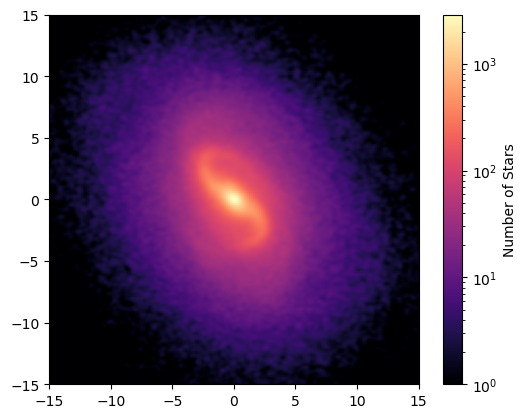

In [12]:
data = np.loadtxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+'.txt')

x = data[:, 1]
y = data[:, 2]

grid_resolution = 3000

ret = binned_statistic_2d(x, y, 
    None,            # Values to calculate (None because we are just counting)
    statistic='count', 
    bins=grid_resolution
)

density_map = ret.statistic
x_edges = ret.x_edge
y_edges = ret.y_edge

smoothed_density = gaussian_filter(density_map, sigma=1)

limit = 15  # Adjust this based on your galaxy's expected size
plt.xlim(-limit, limit)
plt.ylim(-limit, limit)

plt.imshow(smoothed_density.T, origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],cmap='magma',norm=LogNorm(vmin=1))
plt.colorbar(label='Number of Stars')
plt.show()

In [13]:
#quasi shrinking sphere algorithm to center galaxies in TNG (for first use of shrinking sphere see Power+2003)
#set of parameters that works ok RS=half mass radius for stars from TNG catalogues
#Rbig=5*RS
#Rsmall=.25*RS
#dR=(Rbig-Rsmall)/20
#Rvel=RS
def cent1(m,x,y,z,Rbig,dR,Rsmall,vx,vy,vz,Rvel):
    xc0=0.
    yc0=0.
    zc0=0.

    R=Rbig
    xc1=xc0
    yc1=yc0
    zc1=zc0

    while R>=Rsmall:
        xin=[]
        yin=[]
        zin=[]
        mins=[]
        for i in range(len(x)):
            r=np.sqrt((x[i]-xc1)**2+(y[i]-yc1)**2+(z[i]-zc1)**2)  
            if r<=R:
                xin.append(x[i])
                yin.append(y[i])
                zin.append(z[i])
                mins.append(m[i])
        xc1=np.average(xin,weights=mins)
        yc1=np.average(yin,weights=mins)
        zc1=np.average(zin,weights=mins)
        R=R-dR

    vxin=[]
    vyin=[]
    vzin=[]
    mvel=[]
    for i in range(len(x)):
        r=np.sqrt((x[i]-xc1)**2+(y[i]-yc1)**2+(z[i]-zc1)**2)
        if r<=Rvel:
            vxin.append(vx[i])
            vyin.append(vy[i])
            vzin.append(vz[i])
            mvel.append(m[i])

    vxc=np.average(vxin,weights=mvel)
    vyc=np.average(vyin,weights=mvel)
    vzc=np.average(vzin,weights=mvel)
    return xc1,yc1,zc1,vxc,vyc,vzc

In [14]:
RS = 2.5555
Rbig=5*RS
Rsmall=.25*RS
dR=(Rbig-Rsmall)/20
Rvel=RS

In [15]:
#function to get rotation matrix
#to be called 
def get_rotation_matrix(i_v, unit=None):
    # From http://www.j3d.org/matrix_faq/matrfaq_latest.html#Q38
    if unit is None:
        unit = [1.0, 0.0, 0.0]
    # Normalize vector length
    i_v /= np.linalg.norm(i_v)

    # Get axis
    uvw = np.cross(i_v, unit)

    # compute trig values - no need to go through arccos and back
    rcos = np.dot(i_v, unit)
    rsin = np.linalg.norm(uvw)

    #normalize and unpack axis
    if not np.isclose(rsin, 0):
        uvw /= rsin
    u, v, w = uvw

    # Compute rotation matrix - re-expressed to show structure
    return (
        rcos * np.eye(3) +
        rsin * np.array([
            [ 0, -w,  v],
            [ w,  0, -u],
            [-v,  u,  0]
        ]) +
        (1.0 - rcos) * uvw[:,None] * uvw[None,:]
    )

In [16]:
data = np.loadtxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+'.txt')
m = data[:, 0]
x = data[:, 1]
y = data[:, 2]
z = data[:, 3]
vx = data[:, 4]
vy = data[:, 5]
vz = data[:, 6]
t = data[:, 7]

new_coord = cent1(m,x,y,z,Rbig,dR,Rsmall,vx,vy,vz,Rvel)


In [17]:
print(new_coord)

(np.float64(-0.005847818385323527), np.float64(-0.004275763571738284), np.float64(0.0052690544498772765), np.float64(-3.6559884216956555), np.float64(1.424947164514896), np.float64(2.5117336098964733))


In [18]:
x_centered = x-new_coord[0]
y_centered = y-new_coord[1]
z_centered = z-new_coord[2]
vx_centered = vx-new_coord[3]
vy_centered = vy-new_coord[4]
vz_centered = vz-new_coord[5]


In [19]:
outdat_centered=np.transpose((data[:, 0],x_centered,y_centered,z_centered,vx_centered,vy_centered,vz_centered,data[:, 7]))
np.savetxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+"_centered"+'.txt', outdat_centered)


In [20]:
data_centered = np.loadtxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+"_centered"+'.txt')
m_centered = data_centered[:, 0]
x_centered = data_centered[:, 1]
y_centered = data_centered[:, 2]
z_centered = data_centered[:, 3]
vx_centered = data_centered[:, 4]
vy_centered = data_centered[:, 5]
vz_centered = data_centered[:, 6]
t_centered = data_centered[:, 7]

# Calculate 3D distance for all stars at once
dist = np.sqrt(x**2 + y**2 + z**2)

# Create a filter (mask)
mask = dist < (2 * RS)

# Apply the filter
m_cut = m_centered[mask]
x_cut = x_centered[mask]
y_cut = y_centered[mask]
z_cut = z_centered[mask]
vx_cut = vx_centered[mask]
vy_cut = vy_centered[mask]
vz_cut = vz_centered[mask]
t_cut = t_centered[mask]

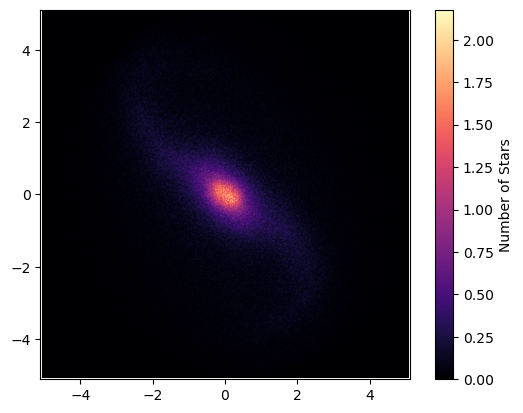

In [38]:
grid_resolution = 3000

ret_cut = binned_statistic_2d(x_cut, y_cut, 
    None,            # Values to calculate (None because we are just counting)
    statistic='count', 
    bins=grid_resolution
)

density_map_cut = ret_cut.statistic
x_edges_cut = ret_cut.x_edge
y_edges_cut = ret_cut.y_edge

smoothed_density_cut = gaussian_filter(density_map_cut, sigma=2)

limit = 2*RS  # Adjust this based on your galaxy's expected size
plt.xlim(-limit, limit)
plt.ylim(-limit, limit)

plt.imshow(smoothed_density_cut.T, origin='lower', extent=[x_edges_cut[0], x_edges_cut[-1], y_edges_cut[0], y_edges_cut[-1]],cmap='magma')
plt.colorbar(label='Number of Stars')
plt.show()

In [22]:
outdat_2RS=np.transpose((m_cut,x_cut,y_cut,z_cut,vx_cut,vy_cut,vz_cut,t_cut))
np.savetxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+"_2RS"+'.txt', outdat_2RS)

In [23]:
r_vec = np.array([x_cut, y_cut, z_cut])
v_vec = np.array([vx_cut, vy_cut, vz_cut])

l_individual = m_cut[:, np.newaxis] * np.cross(r_vec.T, v_vec.T)

L_total = np.sum(l_individual, axis=0)

In [24]:
matrix_rot = get_rotation_matrix(L_total, [0,0,1])

In [25]:
print(L_total,"\n",matrix_rot)

[0.72366969 0.30186429 0.62062882] 
 [[ 0.67685517 -0.13479338 -0.72366969]
 [-0.13479338  0.94377365 -0.30186429]
 [ 0.72366969  0.30186429  0.62062882]]


In [26]:
print(matrix_rot.shape,r_vec.shape,v_vec.shape)

(3, 3) (3, 505442) (3, 505442)


In [40]:
r_vec = np.array([x_centered, y_centered, z_centered])
v_vec = np.array([vx_centered, vy_centered, vz_centered])

r_rot = (matrix_rot @ r_vec)
v_rot = (matrix_rot @ v_vec)

In [41]:
print(r_rot.shape, v_rot.shape)

(3, 792205) (3, 792205)


In [42]:
x_rot = r_rot[0]
y_rot = r_rot[1]
z_rot = r_rot[2]
vx_rot = v_rot[0]
vy_rot = v_rot[1]
vz_rot = v_rot[2]

In [43]:
outdat_rot=np.transpose((m_centered,x_rot,y_rot,z_rot,vx_rot,vy_rot,vz_rot,t_centered))
np.savetxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+"_rot"+'.txt', outdat_rot)

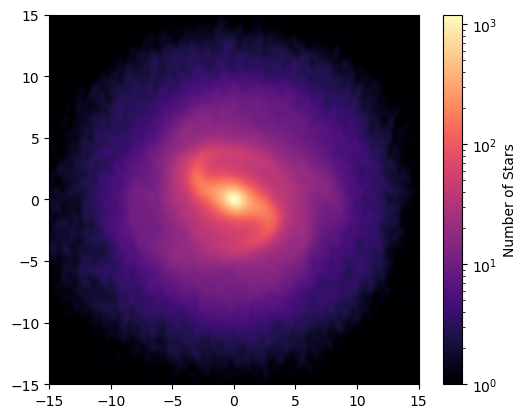

In [69]:
grid_resolution = 3000

ret_rot = binned_statistic_2d(x_rot, y_rot, 
    None,            # Values to calculate (None because we are just counting)
    statistic='count', 
    bins=grid_resolution
)

density_map_rot = ret_rot.statistic
x_edges_rot = ret_rot.x_edge
y_edges_rot = ret_rot.y_edge

smoothed_density_rot = gaussian_filter(density_map_rot, sigma=2)

limit = 15  # Adjust this based on your galaxy's expected size
plt.xlim(-limit, limit)
plt.ylim(-limit, limit)

plt.imshow(smoothed_density_rot.T, origin='lower', extent=[x_edges_rot[0], x_edges_rot[-1], y_edges_rot[0], y_edges_rot[-1]],cmap='magma',norm=LogNorm(vmin=1))
plt.colorbar(label='Number of Stars')
plt.show()

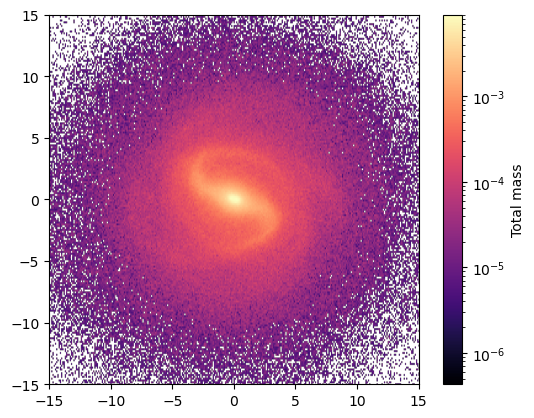

In [72]:
grid_resolution = 3000

ret = binned_statistic_2d(x_rot, y_rot, 
    m_centered,            
    statistic='sum', 
    bins=grid_resolution
)

mass_map = ret.statistic
x_edges = ret.x_edge
y_edges = ret.y_edge

smoothed_density = gaussian_filter(mass_map, sigma=2)

limit = 15  # Adjust this based on your galaxy's expected size
plt.xlim(-limit, limit)
plt.ylim(-limit, limit)

plt.imshow(mass_map.T, origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],cmap='magma',norm=LogNorm())
plt.colorbar(label='Total mass')
plt.show()

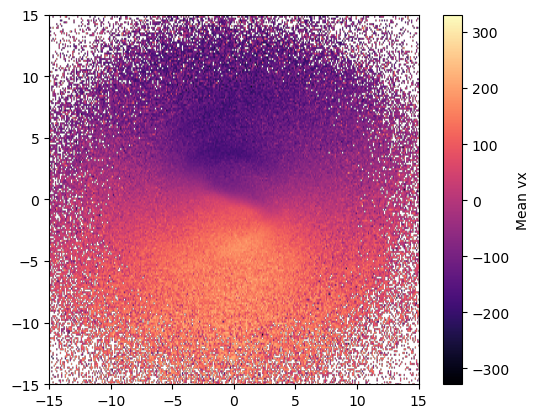

In [76]:
grid_resolution = 3000

ret = binned_statistic_2d(x_rot, y_rot, 
    vx_rot,            
    statistic='mean', 
    bins=grid_resolution
)

meanvx_map = ret.statistic
x_edges = ret.x_edge
y_edges = ret.y_edge

limit = 15  # Adjust this based on your galaxy's expected size
plt.xlim(-limit, limit)
plt.ylim(-limit, limit)

plt.imshow(meanvx_map.T, origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],cmap='magma')
plt.colorbar(label='Mean vx')
plt.show()